# Fraud Detection Notebook

1. Libraries import

In [ ]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier

2. Loading dataset

In [ ]:
fd = pd.read_csv("/content/creditcard.csv")

3. Displaying first 5 rows and basic dataset infomation

In [ ]:
print("First 5 rows:")
print(fd.head())

print("\nDataset Info:")
fd.info()

print("\nClass Distribution:")
print(fd["Class"].value_counts())

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

5. Reducing the size of dataset and defing targets and features

In [ ]:
fd = fd.sample(n=50000, random_state=42)

X = fd.drop(columns=["Class"])
y = fd["Class"]

6. Split dataset into training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

7. Handling imbalance data using scale_pos_weight

In [ ]:
fraud_count = sum(y_train == 1)
normal_count = sum(y_train == 0)

scale_pos_weight_value = normal_count / fraud_count

print("\nClass counts:")
print("Fraud:", fraud_count)
print("Normal:", normal_count)
print("scale_pos_weight:", scale_pos_weight_value)


Class counts:
Fraud: 66
Normal: 39934
scale_pos_weight: 605.060606060606


8. Training model and making prediction

In [ ]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

9. Evaluating model


Accuracy:
0.9993

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.86      0.71      0.77        17

    accuracy                           1.00     10000
   macro avg       0.93      0.85      0.89     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix:


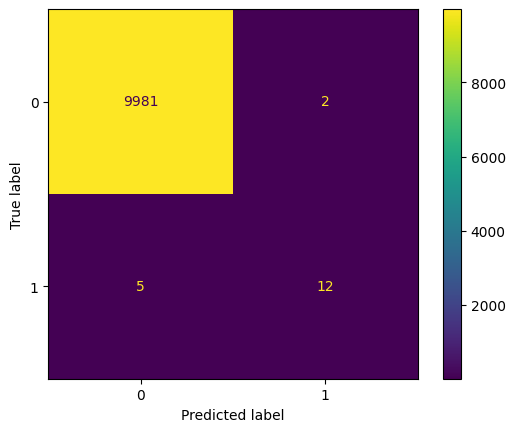

In [ ]:
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
fd_cm = confusion_matrix(y_test, y_pred)
disp_fd_cm = ConfusionMatrixDisplay(fd_cm)
disp_fd_cm.plot ()

10. Importance of features

In [ ]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))


Top 10 Important Features:
V14       0.574299
V8        0.079401
V10       0.071798
V27       0.037211
V11       0.032974
V4        0.029208
V12       0.020306
V19       0.019054
Amount    0.018676
V13       0.018346
dtype: float32


11. Saving model

In [ ]:
with open("fraud_xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("\nFraud XGBoost model saved successfully.")


Fraud XGBoost model saved successfully.
